In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load the data
train_df = pd.read_csv('../../data/raw/train.csv')
test_df = pd.read_csv('../../data/raw/test.csv')

# Save the target variable and ID column
y_train = train_df['SalePrice'].copy()
train_id = train_df['Id'].copy()
test_id = test_df['Id'].copy()

# Drop SalePrice and Id from training data
train_df = train_df.drop(['SalePrice', 'Id'], axis=1)
test_df = test_df.drop(['Id'], axis=1)

print("Data loaded successfully!")
print(f"Training shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Target variable shape: {y_train.shape}")


Data loaded successfully!
Training shape: (1460, 79)
Test shape: (1459, 79)
Target variable shape: (1460,)


In [10]:
# Combine train and test data for consistent preprocessing
ntrain = train_df.shape[0]
ntest = test_df.shape[0]

all_data = pd.concat([train_df, test_df], axis=0, ignore_index=True)

print(f"Combined dataset shape: {all_data.shape}")
print(f"Training samples: {ntrain}")
print(f"Test samples: {ntest}")


Combined dataset shape: (2919, 79)
Training samples: 1460
Test samples: 1459


In [11]:
# Identify numerical columns with missing values
numerical_cols = all_data.select_dtypes(include=[np.number]).columns
missing_numerical = all_data[numerical_cols].isnull().sum()
missing_numerical = missing_numerical[missing_numerical > 0].sort_values(ascending=False)

print("Numerical columns with missing values:")
print("=" * 60)
print(missing_numerical)

# Fill missing values with median
for col in missing_numerical.index:
    all_data[col].fillna(all_data[col].median(), inplace=True)
    print(f"✓ Filled {col} with median: {all_data[col].median():.2f}")

print("\n✅ All numerical missing values handled!")


Numerical columns with missing values:
LotFrontage     486
GarageYrBlt     159
MasVnrArea       23
BsmtFullBath      2
BsmtHalfBath      2
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
GarageCars        1
GarageArea        1
dtype: int64
✓ Filled LotFrontage with median: 68.00
✓ Filled GarageYrBlt with median: 1979.00
✓ Filled MasVnrArea with median: 0.00
✓ Filled BsmtFullBath with median: 0.00
✓ Filled BsmtHalfBath with median: 0.00
✓ Filled BsmtFinSF1 with median: 368.50
✓ Filled BsmtFinSF2 with median: 0.00
✓ Filled BsmtUnfSF with median: 467.00
✓ Filled TotalBsmtSF with median: 989.50
✓ Filled GarageCars with median: 2.00
✓ Filled GarageArea with median: 480.00

✅ All numerical missing values handled!


In [12]:
# Identify categorical columns with missing values
categorical_cols = all_data.select_dtypes(include=['object']).columns
missing_categorical = all_data[categorical_cols].isnull().sum()
missing_categorical = missing_categorical[missing_categorical > 0].sort_values(ascending=False)

print("Categorical columns with missing values:")
print("=" * 60)
print(missing_categorical)

# Fill missing values with mode (most frequent value)
for col in missing_categorical.index:
    mode_value = all_data[col].mode()[0]
    all_data[col].fillna(mode_value, inplace=True)
    print(f"✓ Filled {col} with mode: '{mode_value}'")

print("\n✅ All categorical missing values handled!")

# Verify no missing values remain
print(f"\nTotal missing values remaining: {all_data.isnull().sum().sum()}")


Categorical columns with missing values:
PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
GarageQual       159
GarageFinish     159
GarageCond       159
GarageType       157
BsmtCond          82
BsmtExposure      82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MSZoning           4
Functional         2
Utilities          2
Electrical         1
KitchenQual        1
Exterior2nd        1
Exterior1st        1
SaleType           1
dtype: int64
✓ Filled PoolQC with mode: 'Ex'
✓ Filled MiscFeature with mode: 'Shed'
✓ Filled Alley with mode: 'Grvl'
✓ Filled Fence with mode: 'MnPrv'
✓ Filled MasVnrType with mode: 'BrkFace'
✓ Filled FireplaceQu with mode: 'Gd'
✓ Filled GarageQual with mode: 'TA'
✓ Filled GarageFinish with mode: 'Unf'
✓ Filled GarageCond with mode: 'TA'
✓ Filled GarageType with mode: 'Attchd'
✓ Filled BsmtCond with mode: 'TA'
✓ Filled BsmtExposure with mode: 'No'
✓ Filled BsmtQual with m

Q1 (25th percentile): $129,975.00
Q3 (75th percentile): $214,000.00
IQR: $84,025.00
Lower bound: $3,937.50
Upper bound: $340,037.50

Number of outliers detected: 61


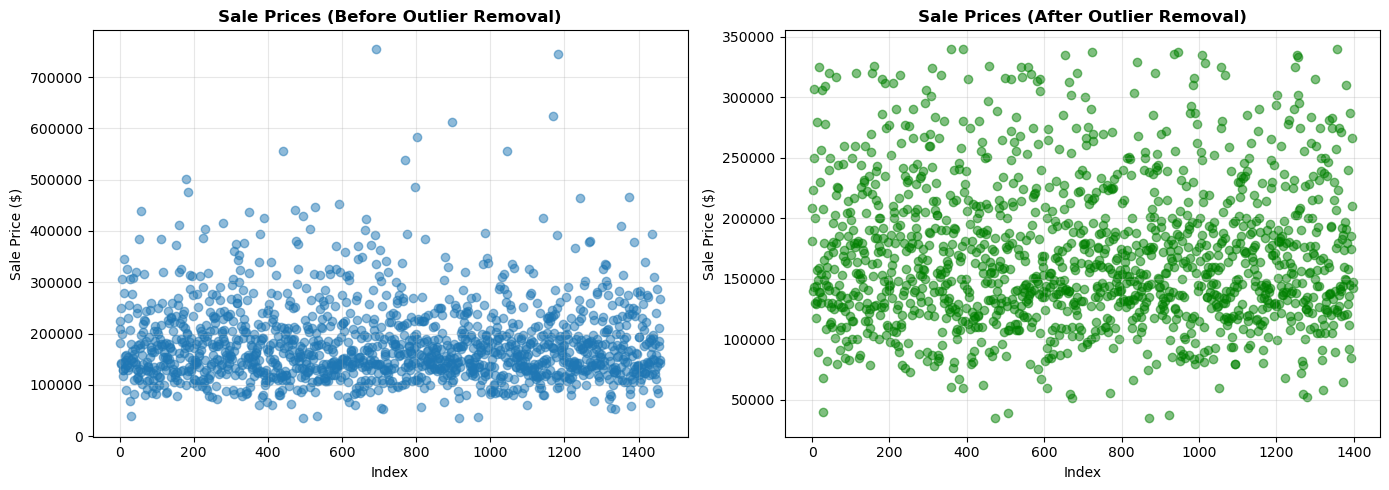


Original training size: 1460
Cleaned training size: 1399
Removed samples: 61


In [13]:
# Note: We only remove outliers from training data, not test data
# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before removing outliers
axes[0].scatter(range(len(y_train)), y_train, alpha=0.5)
axes[0].set_title('Sale Prices (Before Outlier Removal)', fontweight='bold')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Sale Price ($)')
axes[0].grid(True, alpha=0.3)

# Calculate IQR
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): ${Q1:,.2f}")
print(f"Q3 (75th percentile): ${Q3:,.2f}")
print(f"IQR: ${IQR:,.2f}")
print(f"Lower bound: ${lower_bound:,.2f}")
print(f"Upper bound: ${upper_bound:,.2f}")

# Identify outliers
outliers = (y_train < lower_bound) | (y_train > upper_bound)
print(f"\nNumber of outliers detected: {outliers.sum()}")

# Remove outliers from training data
train_df_clean = train_df.iloc[:ntrain][~outliers].reset_index(drop=True)
y_train_clean = y_train[~outliers].reset_index(drop=True)

# After removing outliers
axes[1].scatter(range(len(y_train_clean)), y_train_clean, alpha=0.5, color='green')
axes[1].set_title('Sale Prices (After Outlier Removal)', fontweight='bold')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Sale Price ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../visualizations/outlier_removal.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nOriginal training size: {ntrain}")
print(f"Cleaned training size: {len(train_df_clean)}")
print(f"Removed samples: {ntrain - len(train_df_clean)}")

# Update combined data (remove outliers from train portion only)
all_data = pd.concat([train_df_clean, test_df], axis=0, ignore_index=True)
ntrain = len(train_df_clean)


In [14]:
# Get list of categorical columns
categorical_features = all_data.select_dtypes(include=['object']).columns

print(f"Number of categorical features: {len(categorical_features)}")
print("\nEncoding categorical variables using One-Hot Encoding...")
print("=" * 60)

# One-hot encoding
all_data_encoded = pd.get_dummies(all_data, columns=categorical_features, drop_first=True)

print(f"\nShape before encoding: {all_data.shape}")
print(f"Shape after encoding: {all_data_encoded.shape}")
print(f"New features created: {all_data_encoded.shape[1] - all_data.shape[1] + len(categorical_features)}")

print("\n✅ Categorical encoding completed!")


Number of categorical features: 43

Encoding categorical variables using One-Hot Encoding...

Shape before encoding: (2858, 79)
Shape after encoding: (2858, 244)
New features created: 208

✅ Categorical encoding completed!


In [15]:
# Initialize scaler
scaler = StandardScaler()

# Fit on all data and transform
all_data_scaled = scaler.fit_transform(all_data_encoded)

# Convert back to DataFrame
all_data_scaled = pd.DataFrame(
    all_data_scaled, 
    columns=all_data_encoded.columns
)

print("Feature scaling completed!")
print(f"Scaled data shape: {all_data_scaled.shape}")
print("\nSample statistics after scaling:")
print(all_data_scaled.describe().iloc[:, :5])  # Show first 5 columns


Feature scaling completed!
Scaled data shape: (2858, 244)

Sample statistics after scaling:
         MSSubClass   LotFrontage       LotArea   OverallQual   OverallCond
count  2.858000e+03  2.375000e+03  2.858000e+03  2.858000e+03  2.858000e+03
mean   6.650461e-17 -1.047116e-17 -9.198769e-17 -1.168492e-16 -3.393600e-16
std    1.000175e+00  1.000211e+00  1.000175e+00  1.000175e+00  1.000175e+00
min   -8.753979e-01 -2.072339e+00 -1.274045e+00 -3.690073e+00 -4.097916e+00
25%   -8.753979e-01 -4.685803e-01 -3.777512e-01 -7.568986e-01 -5.127491e-01
50%   -1.738031e-01 -3.513212e-02 -9.150634e-02 -2.360497e-02 -5.127491e-01
75%    2.939268e-01  4.850057e-01  2.096670e-01  7.096886e-01  3.835426e-01
max    3.100306e+00  1.058435e+01  2.269364e+01  2.909569e+00  3.072418e+00


In [16]:
# Split back into training and test sets
X_train = all_data_scaled[:ntrain]
X_test = all_data_scaled[ntrain:]

print("=" * 60)
print("FINAL PREPROCESSED DATA")
print("=" * 60)
print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train_clean.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nTotal features: {X_train.shape[1]}")


FINAL PREPROCESSED DATA

X_train shape: (1399, 244)
y_train shape: (1399,)
X_test shape: (1459, 244)

Total features: 244


In [17]:
# Save preprocessed data
X_train.to_csv('../../data/processed/X_train_processed.csv', index=False)
X_test.to_csv('../../data/processed/X_test_processed.csv', index=False)
y_train_clean.to_csv('../../data/processed/y_train_processed.csv', index=False, header=['SalePrice'])
test_id.to_csv('../../data/processed/test_ids.csv', index=False, header=['Id'])

print("✅ Preprocessed data saved successfully!")
print("\nSaved files:")
print("  ✓ data/processed/X_train_processed.csv")
print("  ✓ data/processed/X_test_processed.csv")
print("  ✓ data/processed/y_train_processed.csv")
print("  ✓ data/processed/test_ids.csv")

print("\n" + "=" * 60)
print("✅ DATA PREPROCESSING COMPLETED!")
print("=" * 60)
print("\nNext Steps:")
print("1. Open notebook: 03_model_training_and_evaluation.ipynb")
print("2. Start training machine learning models")


✅ Preprocessed data saved successfully!

Saved files:
  ✓ data/processed/X_train_processed.csv
  ✓ data/processed/X_test_processed.csv
  ✓ data/processed/y_train_processed.csv
  ✓ data/processed/test_ids.csv

✅ DATA PREPROCESSING COMPLETED!

Next Steps:
1. Open notebook: 03_model_training_and_evaluation.ipynb
2. Start training machine learning models
